# 聲納影像異常偵測系統
**方法：PatchCore（無監督異常偵測）+ MobileNetV3 類型分類器**

## 流程概覽
1. 環境安裝與設定
2. 參數設定
3. 特徵提取器（WideResNet50）
4. **[新增] 聲納類型分類器（MobileNetV3）**
5. Memory Bank 建立（正掃 + 側掃各一個）
6. 影片推論（自動偵測類型）
7. 結果視覺化與閾值調整


## Cell 1 — 安裝套件

In [ ]:
# 第一次執行時需要安裝，之後可以跳過
!pip install torch torchvision opencv-python-headless tqdm matplotlib scikit-learn


## Cell 2 — 匯入套件

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

print(f"PyTorch 版本：{torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU：{torch.cuda.get_device_name(0)}")


PyTorch 版本：1.12.1
CUDA 可用：True
GPU：NVIDIA GeForce RTX 3090


## Cell 3 — 參數設定
**所有參數集中在這裡，方便調整**

In [3]:
# ============================================================
#  請根據你的環境修改以下路徑與參數
# ============================================================

# --- 正常影像資料夾（分兩種類型）---
NORMAL_IMAGE_DIR_FORWARD  = "./normal"    # 正掃正常影像
NORMAL_IMAGE_DIR_SIDESCAN = "./sidescan"   # 側掃正常影像

# --- Memory Bank 儲存路徑 ---
MEMORY_BANK_PATH_FORWARD  = "./memory_bank_forward.pt"
MEMORY_BANK_PATH_SIDESCAN = "./memory_bank_sidescan.pt"

# --- 類型分類器 ---
CLASSIFIER_DATA_DIR  = "./classifier_data"        # 訓練資料夾（見 Cell 4a）
CLASSIFIER_PATH      = "./sonar_classifier.pt"    # 分類器儲存路徑
CLASSIFIER_EPOCHS    = 10                          # 訓練 epoch 數
CLASSIFIER_BATCH     = 32

# --- 影像前處理 ---
IMAGE_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# --- PatchCore 參數 ---
SAMPLE_RATIO    = 0.1
KNN_N_NEIGHBORS = 9

# --- Stage 1 規則篩選 ---
BRIGHTNESS_LOW  = 5
BRIGHTNESS_HIGH = 250

# --- 影片處理 ---
SAMPLE_FRAMES          = 20
AGGREGATION_PERCENTILE = 90

# --- 異常判斷閾值（兩種類型分開校準）---
ANOMALY_THRESHOLD_FORWARD  = 0.5   # 待校準
ANOMALY_THRESHOLD_SIDESCAN = 0.5   # 待校準（側掃通常不同）

# --- 裝置 ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置：{DEVICE}")


使用裝置：cuda


## Cell 4 — 特徵提取器
使用 WideResNet50 的 `layer2` + `layer3` 中間層特徵

In [4]:
class FeatureExtractor(nn.Module):
    """
    從 WideResNet50 提取 layer2 + layer3 的中間層特徵
    - layer2：捕捉紋理、細節特徵
    - layer3：捕捉結構、形狀特徵
    兩層融合後能更全面描述正常影像的分布
    """
    def __init__(self):
        super().__init__()
        backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        for param in self.parameters():
            param.requires_grad = False
        self.eval()

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        feat2 = self.layer2(x)
        feat3 = self.layer3(feat2)
        return feat2, feat3


def fuse_features(feat2, feat3):
    target_h, target_w = feat2.shape[2], feat2.shape[3]
    feat3_up = nn.functional.interpolate(
        feat3, size=(target_h, target_w), mode="bilinear", align_corners=False
    )
    fused = torch.cat([feat2, feat3_up], dim=1)  # [B, 1536, H, W]
    return fused


def extract_patch_features(fused_feat):
    B, C, H, W = fused_feat.shape
    patches = fused_feat.permute(0, 2, 3, 1).reshape(-1, C)
    return patches.cpu().numpy()


# 初始化特徵提取器
extractor = FeatureExtractor().to(DEVICE)
print("✅ 特徵提取器初始化完成")

# 影像前處理 transform（PatchCore 用）
transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])


✅ 特徵提取器初始化完成


## Cell 4a — 聲納類型分類器訓練（MobileNetV3）
**只需執行一次**，訓練完成後儲存為 `sonar_classifier.pt`

### 資料夾結構
```
classifier_data/
├── train/
│   ├── forward/     ← 從 normal/forward 複製約 400 張
│   └── sidescan/    ← 從 normal/sidescan 複製約 400 張
└── val/
    ├── forward/     ← 各留約 100 張
    └── sidescan/
```
> **注意**：執行完後請確認印出的 `class_to_idx`，確保 forward/sidescan 對應的索引與 `IDX_TO_TYPE` 一致。


In [ ]:
# --- 資料前處理 ---
clf_train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])
clf_val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

train_ds = ImageFolder(str(Path(CLASSIFIER_DATA_DIR) / "train"), transform=clf_train_transform)
val_ds   = ImageFolder(str(Path(CLASSIFIER_DATA_DIR) / "val"),   transform=clf_val_transform)
train_loader = DataLoader(train_ds, batch_size=CLASSIFIER_BATCH, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CLASSIFIER_BATCH, shuffle=False, num_workers=2)

# !! 重要：確認 class_to_idx，確保和下方 IDX_TO_TYPE 一致 !!
print("class_to_idx:", train_ds.class_to_idx)
# 預期輸出：{'forward': 0, 'sidescan': 1}（字母排序）
# 如果順序相反，請對調下方 IDX_TO_TYPE 的值

# --- 模型：MobileNetV3-Small，輕量適合筆電 ---
sonar_classifier = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
)
sonar_classifier.classifier[3] = nn.Linear(
    sonar_classifier.classifier[3].in_features, 2
)
sonar_classifier = sonar_classifier.to(DEVICE)

optimizer = torch.optim.Adam(sonar_classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# --- 訓練 ---
best_acc = 0.0
for epoch in range(CLASSIFIER_EPOCHS):
    sonar_classifier.train()
    train_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(sonar_classifier(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 驗證
    sonar_classifier.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = sonar_classifier(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += len(labels)
    val_acc = correct / total
    print(f"Epoch {epoch+1:02d}/{CLASSIFIER_EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Acc: {val_acc:.2%}")

    # 儲存最佳模型
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(sonar_classifier.state_dict(), CLASSIFIER_PATH)

print(f"\n✅ 分類器訓練完成，最佳 Val Acc: {best_acc:.2%}")
print(f"✅ 已儲存至 {CLASSIFIER_PATH}")


## Cell 4b — 載入類型分類器
訓練完成後，之後每次只需執行此 Cell 載入即可。


In [27]:
# !! 請確認此對應與訓練時的 class_to_idx 一致 !!
IDX_TO_TYPE = {0: "forward", 1: "sidescan"}

sonar_classifier = models.mobilenet_v3_small()
sonar_classifier.classifier[3] = nn.Linear(
    sonar_classifier.classifier[3].in_features, 2
)
sonar_classifier.load_state_dict(
    torch.load(CLASSIFIER_PATH, map_location=DEVICE)
)
sonar_classifier = sonar_classifier.to(DEVICE).eval()
print("✅ 類型分類器載入完成")
print(f"   IDX_TO_TYPE: {IDX_TO_TYPE}")


def detect_sonar_type(frames: list) -> str:
    """
    輸入幾幀 BGR numpy array，投票決定聲納類型
    取前 3 幀即可，速度快
    回傳：'forward' 或 'sidescan'
    """
    votes = []
    with torch.no_grad():
        for frame in frames[:3]:
            img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            tensor = transform(img).unsqueeze(0).to(DEVICE)
            pred = sonar_classifier(tensor).argmax(dim=1).item()
            votes.append(pred)
    result_idx = max(set(votes), key=votes.count)
    return IDX_TO_TYPE[result_idx]


print("✅ detect_sonar_type 函式準備完成")


✅ 類型分類器載入完成
   IDX_TO_TYPE: {0: 'forward', 1: 'sidescan'}
✅ detect_sonar_type 函式準備完成


## Cell 5 — Stage 1：規則篩選函式
快速偵測「無畫面」（全黑/過曝）的幀，不需要模型

In [28]:
def is_blank_frame(frame_bgr, low=BRIGHTNESS_LOW, high=BRIGHTNESS_HIGH):
    """
    規則篩選：判斷是否為無畫面幀
    - 轉成灰階後計算平均亮度
    - 過暗（< low）或過亮（> high）都視為異常
    回傳：(is_blank: bool, mean_brightness: float)
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    mean_brightness = gray.mean()
    is_blank = (mean_brightness < low) or (mean_brightness > high)
    return is_blank, mean_brightness

print("✅ Stage 1 規則篩選函式準備完成")


✅ Stage 1 規則篩選函式準備完成


## Cell 6 — 隨機取樣（快速版）
隨機從所有特徵中取樣子集來建立 Memory Bank

> **說明：** 這是測試用的快速版本，速度比 CoreSet 快 10 倍以上。
> 流程穩定、閾值調好之後，可以再換成 CoreSet 版本提升精度。


In [29]:
def random_sampling(features: np.ndarray, ratio: float = SAMPLE_RATIO) -> np.ndarray:
    n_select = max(1, int(len(features) * ratio))
    indices = np.random.choice(len(features), n_select, replace=False)
    print(f"  隨機取樣：從 {len(features)} 個特徵中挑選 {n_select} 個")
    return features[indices]

print("✅ 隨機取樣函式準備完成")


✅ 隨機取樣函式準備完成


## Cell 7 — 建立 Memory Bank（Training Phase）
**只需執行一次**，正掃與側掃各建一個，分別儲存。


In [30]:
def build_memory_bank(image_dir: str, save_path: str):
    """
    從正常影像資料夾建立 Memory Bank：
    1. 讀取所有正常影像
    2. 提取 patch 特徵
    3. 隨機取樣壓縮
    4. 建立 sklearn NearestNeighbors 並儲存
    """
    image_paths = sorted([
        p for p in Path(image_dir).glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])
    if len(image_paths) == 0:
        raise ValueError(f"在 {image_dir} 找不到影像檔案，請確認路徑是否正確")
    print(f"找到 {len(image_paths)} 張正常影像")

    all_patch_features = []
    with torch.no_grad():
        for img_path in tqdm(image_paths, desc="提取特徵"):
            img = Image.open(img_path).convert("RGB")
            tensor = transform(img).unsqueeze(0).to(DEVICE)
            feat2, feat3 = extractor(tensor)
            fused = fuse_features(feat2, feat3)
            patches = extract_patch_features(fused)
            all_patch_features.append(patches)

    all_features = np.concatenate(all_patch_features, axis=0).astype(np.float32)
    print(f"原始特徵數量：{len(all_features)}")

    memory_bank = random_sampling(all_features, ratio=SAMPLE_RATIO)
    print(f"壓縮後 Memory Bank 大小：{len(memory_bank)}")

    print("建立 NearestNeighbors index...")
    knn = NearestNeighbors(n_neighbors=KNN_N_NEIGHBORS, metric="euclidean",
                           algorithm="ball_tree", n_jobs=-1)
    knn.fit(memory_bank)

    torch.save({"memory_bank": memory_bank, "feature_dim": memory_bank.shape[1]}, save_path)
    print(f"✅ Memory Bank 已儲存至 {save_path}")
    return knn


# --- 建立正掃 Memory Bank ---
print("=" * 50)
print("建立正掃 Memory Bank...")
if not Path(MEMORY_BANK_PATH_FORWARD).exists():
    knn_forward = build_memory_bank(NORMAL_IMAGE_DIR_FORWARD, MEMORY_BANK_PATH_FORWARD)
else:
    print(f"已存在，跳過建立。若要重建請刪除 {MEMORY_BANK_PATH_FORWARD}")

# --- 建立側掃 Memory Bank ---
print("=" * 50)
print("建立側掃 Memory Bank...")
if not Path(MEMORY_BANK_PATH_SIDESCAN).exists():
    knn_sidescan = build_memory_bank(NORMAL_IMAGE_DIR_SIDESCAN, MEMORY_BANK_PATH_SIDESCAN)
else:
    print(f"已存在，跳過建立。若要重建請刪除 {MEMORY_BANK_PATH_SIDESCAN}")


建立正掃 Memory Bank...
已存在，跳過建立。若要重建請刪除 ./memory_bank_forward.pt
建立側掃 Memory Bank...
已存在，跳過建立。若要重建請刪除 ./memory_bank_sidescan.pt


## Cell 8 — 載入兩個 Memory Bank

In [31]:
def load_memory_bank(save_path: str):
    data = torch.load(save_path, map_location="cpu")
    memory_bank = data["memory_bank"]
    knn = NearestNeighbors(n_neighbors=KNN_N_NEIGHBORS, metric="euclidean",
                           algorithm="ball_tree", n_jobs=-1)
    knn.fit(memory_bank)
    print(f"✅ Memory Bank 載入完成，共 {len(memory_bank)} 個向量：{save_path}")
    return knn


knn_forward  = load_memory_bank(MEMORY_BANK_PATH_FORWARD)
knn_sidescan = load_memory_bank(MEMORY_BANK_PATH_SIDESCAN)


✅ Memory Bank 載入完成，共 45628 個向量：./memory_bank_forward.pt
✅ Memory Bank 載入完成，共 41708 個向量：./memory_bank_sidescan.pt


## Cell 9 — 單幀異常分數計算

In [32]:
def compute_frame_anomaly_score(frame_bgr: np.ndarray, index) -> float:
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feat2, feat3 = extractor(tensor)
        fused = fuse_features(feat2, feat3)
        patches = extract_patch_features(fused).astype(np.float32)

    distances, _ = index.kneighbors(patches)
    patch_scores = distances.mean(axis=1)
    frame_score = patch_scores.max()
    return float(frame_score)

print("✅ 單幀異常分數計算函式準備完成")


✅ 單幀異常分數計算函式準備完成


## Cell 10 — 影片推論主函式（自動偵測類型）
不再需要手動指定 `sonar_type`，前幾幀投票自動決定。


In [33]:
def analyze_video(video_path: str, threshold_forward: float = ANOMALY_THRESHOLD_FORWARD,
                  threshold_sidescan: float = ANOMALY_THRESHOLD_SIDESCAN):
    """
    分析一段影片：
    0. 自動偵測聲納類型（forward / sidescan）
    1. Stage 1：規則篩選（全黑/過曝）
    2. Stage 2：PatchCore 異常偵測
    3. 聚合多幀分數 → 整段判斷

    回傳 dict 包含：video_path, sonar_type, is_anomaly, anomaly_score,
                    frame_scores, sampled_frame_ids, stage1_triggered, fps, total_frames
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"無法開啟影片：{video_path}")

    fps          = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"影片：{Path(video_path).name} | FPS: {fps:.1f} | 總幀數: {total_frames}")

    # 均勻取樣幀的索引
    sample_ids = np.linspace(0, total_frames - 1, SAMPLE_FRAMES, dtype=int).tolist()

    # ── Step 0：讀取前 3 幀用於類型判斷 ──────────────────────────
    early_frames = []
    for fid in sample_ids[:3]:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
        ret, f = cap.read()
        if ret:
            early_frames.append(f)

    sonar_type = detect_sonar_type(early_frames) if early_frames else "forward"
    knn       = knn_forward  if sonar_type == "forward"  else knn_sidescan
    threshold = threshold_forward if sonar_type == "forward" else threshold_sidescan
    print(f"  偵測類型：{sonar_type} | 使用閾值：{threshold}")

    # ── Step 1 & 2：逐幀分析 ─────────────────────────────────────
    frame_scores     = []
    stage1_triggered = False

    for frame_id in tqdm(sample_ids, desc="分析幀"):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()
        if not ret:
            continue

        is_blank, brightness = is_blank_frame(frame)
        if is_blank:
            stage1_triggered = True
            print(f"  ⚠️  Stage 1 觸發！幀 {frame_id}，亮度={brightness:.1f}")
            frame_scores.append(99999.0)
            continue

        score = compute_frame_anomaly_score(frame, knn)
        frame_scores.append(score)

    cap.release()

    if len(frame_scores) == 0:
        print("警告：沒有成功讀取任何幀")
        return None

    valid_scores = [s for s in frame_scores if s < 99999.0]
    aggregated_score = (
        np.percentile(valid_scores, AGGREGATION_PERCENTILE)
        if valid_scores else 99999.0
    )

    is_anomaly = stage1_triggered or (aggregated_score > threshold)

    result = {
        "video_path"        : video_path,
        "sonar_type"        : sonar_type,
        "is_anomaly"        : is_anomaly,
        "anomaly_score"     : aggregated_score,
        "frame_scores"      : frame_scores,
        "sampled_frame_ids" : sample_ids,
        "stage1_triggered"  : stage1_triggered,
        "fps"               : fps,
        "total_frames"      : total_frames,
    }

    status = "🔴 異常" if is_anomaly else "🟢 正常"
    print(f"\n結果：{status} | 類型：{sonar_type} | 異常分數：{aggregated_score:.4f}")
    return result

print("✅ 影片推論函式準備完成")


✅ 影片推論函式準備完成


## Cell 11 — 結果視覺化函式

In [34]:
def visualize_result(result: dict):
    """
    視覺化影片分析結果，閾值自動根據 sonar_type 選取
    """
    threshold = (
        ANOMALY_THRESHOLD_FORWARD
        if result.get("sonar_type") == "forward"
        else ANOMALY_THRESHOLD_SIDESCAN
    )
    scores    = result["frame_scores"]
    frame_ids = result["sampled_frame_ids"]

    display_scores = [min(s, threshold * 3) for s in scores]

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["red" if s > threshold else "steelblue" for s in scores]
    ax.bar(range(len(scores)), display_scores, color=colors, alpha=0.7)
    ax.plot(range(len(scores)), display_scores, color="navy", linewidth=1.5,
            marker="o", markersize=4)
    ax.axhline(y=threshold, color="red", linestyle="--", linewidth=2,
               label=f"閾值 = {threshold}")

    valid_scores = [s for s in scores if s < 99999.0]
    p90 = np.percentile(valid_scores, AGGREGATION_PERCENTILE) if valid_scores else 0
    ax.axhline(y=p90, color="orange", linestyle="-.", linewidth=2,
               label=f"P90 = {p90:.4f}")

    ax.set_xticks(range(len(scores)))
    ax.set_xticklabels([str(f) for f in frame_ids], rotation=45, fontsize=8)

    status = "🔴 異常" if result["is_anomaly"] else "🟢 正常"
    stype  = result.get("sonar_type", "unknown")
    ax.set_title(f"{Path(result['video_path']).name}  [{stype}]  — {status}", fontsize=13)
    ax.set_xlabel("幀索引")
    ax.set_ylabel("異常分數")

    normal_patch  = mpatches.Patch(color="steelblue", alpha=0.7, label="正常幀")
    anomaly_patch = mpatches.Patch(color="red",       alpha=0.7, label="異常幀")
    ax.legend(handles=[normal_patch, anomaly_patch,
                        plt.Line2D([0], [0], color="red",    linestyle="--", label=f"閾值={threshold}"),
                        plt.Line2D([0], [0], color="orange", linestyle="-.", label=f"P90={p90:.4f}")])
    plt.tight_layout()
    plt.show()


In [36]:
import time
TEST_VIDEO_PATH = "sorted_data/normal/2026_03_19_15_55_15_3_video.mp4"
# 測單幀速度分解
cap = cv2.VideoCapture(TEST_VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
_, frame = cap.read()
cap.release()

# 類型判斷
t0 = time.time()
stype = detect_sonar_type([frame])
print(f"類型判斷：{(time.time()-t0)*1000:.1f} ms")

# 特徵提取
t0 = time.time()
img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
tensor = transform(img).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    feat2, feat3 = extractor(tensor)
    fused = fuse_features(feat2, feat3)
    patches = extract_patch_features(fused)
print(f"特徵提取：{(time.time()-t0)*1000:.1f} ms")

# KNN 搜尋
t0 = time.time()
knn_forward.kneighbors(patches.astype(np.float32))
print(f"KNN 搜尋：{(time.time()-t0)*1000:.1f} ms")

print(f"\n裝置：{DEVICE} | patches shape：{patches.shape}")

類型判斷：19.0 ms
特徵提取：65.3 ms
KNN 搜尋：16552.6 ms

裝置：cuda | patches shape：(784, 1536)


## Cell 12 — 單一影片推論（快速測試）

影片：2026_03_19_15_55_15_3_video.mp4 | FPS: 20.0 | 總幀數: 200
  偵測類型：forward | 使用閾值：0.5


分析幀: 100%|██████████| 20/20 [05:23<00:00, 16.20s/it]
C:\Users\user\AppData\Local\Temp\ipykernel_63464\940923649.py:42: UserWarning: Glyph 24128 (\N{CJK UNIFIED IDEOGRAPH-5E40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63464\940923649.py:42: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63464\940923649.py:42: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63464\940923649.py:42: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63464\940923649.py:42: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63464\940


結果：🔴 異常 | 類型：forward | 異常分數：4.9544


c:\Users\user\AppData\Local\miniconda3\envs\testenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\miniconda3\envs\testenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\miniconda3\envs\testenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\miniconda3\envs\testenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\miniconda3\envs\testenv\lib\

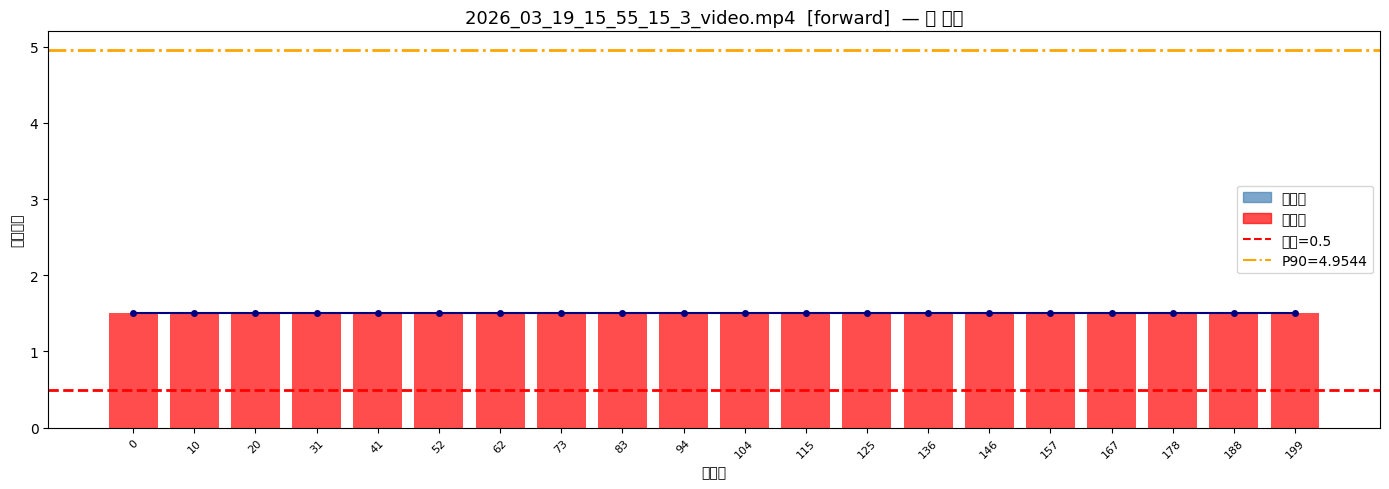

In [37]:
# 修改成你的影片路徑（正掃或側掃都可以，類型會自動判斷）
TEST_VIDEO_PATH = "sorted_data/normal/2026_03_19_15_55_15_3_video.mp4"

result = analyze_video(TEST_VIDEO_PATH)

if result:
    visualize_result(result)


## Cell 13 — 批次推論（驗證集評估）
用正常 + 異常影片評估效果，並分類型找最佳閾值

```
sorted_data/
├── normal/
│   ├── forward/
│   └── sidescan/
└── anomaly/
    ├── forward/
    └── sidescan/
```


In [ ]:
VAL_NORMAL_FORWARD   = "sorted_data/normal/forward"
VAL_NORMAL_SIDESCAN  = "sorted_data/normal/sidescan"
VAL_ANOMALY_FORWARD  = "sorted_data/anomaly/forward"
VAL_ANOMALY_SIDESCAN = "sorted_data/anomaly/sidescan"

VIDEO_EXTENSIONS = [".mp4", ".avi", ".mov", ".mkv"]

def get_video_paths(directory):
    return sorted([
        str(p) for p in Path(directory).glob("*")
        if p.suffix.lower() in VIDEO_EXTENSIONS
    ])

all_results = []
all_labels  = []   # 0 = 正常, 1 = 異常
all_scores  = []
all_types   = []

for label, dirs in [
    (0, [VAL_NORMAL_FORWARD, VAL_NORMAL_SIDESCAN]),
    (1, [VAL_ANOMALY_FORWARD, VAL_ANOMALY_SIDESCAN]),
]:
    tag = "正常" if label == 0 else "異常"
    for d in dirs:
        print(f"\n--- 分析{tag}影片：{d} ---")
        for vp in get_video_paths(d):
            r = analyze_video(vp)
            if r:
                all_results.append(r)
                all_labels.append(label)
                all_scores.append(r["anomaly_score"])
                all_types.append(r["sonar_type"])

print(f"\n✅ 批次推論完成，共分析 {len(all_results)} 支影片")
forward_count  = all_types.count("forward")
sidescan_count = all_types.count("sidescan")
print(f"   正掃：{forward_count} 支 | 側掃：{sidescan_count} 支")


## Cell 14 — 評估指標與閾值分析（分類型）

In [ ]:
from sklearn.metrics import roc_curve

scores_arr = np.array(all_scores)
labels_arr = np.array(all_labels)
types_arr  = np.array(all_types)

for stype in ["forward", "sidescan"]:
    mask = types_arr == stype
    if mask.sum() == 0:
        continue
    s = scores_arr[mask]
    l = labels_arr[mask]
    print(f"\n{'='*50}")
    print(f"類型：{stype}  ({mask.sum()} 支影片)")

    if len(np.unique(l)) > 1:
        auc = roc_auc_score(l, s)
        fpr, tpr, thresholds = roc_curve(l, s)
        print(f"AUC-ROC：{auc:.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].hist(s[l == 0], bins=20, alpha=0.7, color="steelblue", label="正常")
        axes[0].hist(s[l == 1], bins=20, alpha=0.7, color="red",       label="異常")
        thr = ANOMALY_THRESHOLD_FORWARD if stype == "forward" else ANOMALY_THRESHOLD_SIDESCAN
        axes[0].axvline(x=thr, color="black", linestyle="--", label=f"當前閾值={thr}")
        axes[0].set_title(f"[{stype}] 異常分數分布")
        axes[0].legend()

        axes[1].plot(fpr, tpr, color="darkorange", linewidth=2, label=f"AUC={auc:.4f}")
        axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
        axes[1].set_title(f"[{stype}] ROC 曲線")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

        print(f"\n各閾值對應指標：")
        print(f"{'閾值':>10} | {'正確率':>8} | {'召回率':>8} | {'誤報率':>8}")
        print("-" * 45)
        for t in sorted(set(np.percentile(s, np.arange(10, 100, 10)))):
            preds = (s > t).astype(int)
            tp = ((preds==1)&(l==1)).sum(); fp = ((preds==1)&(l==0)).sum()
            fn = ((preds==0)&(l==1)).sum(); tn = ((preds==0)&(l==0)).sum()
            recall  = tp/(tp+fn) if (tp+fn)>0 else 0
            fpr_val = fp/(fp+tn) if (fp+tn)>0 else 0
            acc     = (tp+tn)/len(l)
            print(f"{t:>10.4f} | {acc:>8.2%} | {recall:>8.2%} | {fpr_val:>8.2%}")
    else:
        print("標籤只有一類，無法計算 AUC")


## Cell 15 — 混淆矩陣（使用當前閾值）

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, stype, thr in [
    (axes[0], "forward",  ANOMALY_THRESHOLD_FORWARD),
    (axes[1], "sidescan", ANOMALY_THRESHOLD_SIDESCAN),
]:
    mask = types_arr == stype
    if mask.sum() == 0:
        ax.set_title(f"[{stype}] 無資料")
        continue
    preds = (scores_arr[mask] > thr).astype(int)
    cm = confusion_matrix(labels_arr[mask], preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["正常", "異常"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"[{stype}] 閾值 = {thr}")

plt.tight_layout()
plt.show()


## Cell 16 — 互動式閾值調整
分別調整正掃與側掃的閾值，重新執行此 Cell 查看效果


In [ ]:
NEW_THRESHOLD_FORWARD  = ANOMALY_THRESHOLD_FORWARD
NEW_THRESHOLD_SIDESCAN = ANOMALY_THRESHOLD_SIDESCAN

for stype, new_thr in [("forward", NEW_THRESHOLD_FORWARD),
                        ("sidescan", NEW_THRESHOLD_SIDESCAN)]:
    mask = types_arr == stype
    if mask.sum() == 0:
        continue
    s = scores_arr[mask]
    l = labels_arr[mask]
    preds = (s > new_thr).astype(int)
    cm = confusion_matrix(l, preds)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        recall    = tp/(tp+fn) if (tp+fn)>0 else 0
        precision = tp/(tp+fp) if (tp+fp)>0 else 0
        accuracy  = (tp+tn)/len(l)
        f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
        print(f"[{stype}] 閾值：{new_thr}")
        print(f"  準確率：{accuracy:.2%}  召回率：{recall:.2%}  精確率：{precision:.2%}  F1：{f1:.4f}")
        print(f"  誤報(FP)：{fp}  漏報(FN)：{fn}\n")


## Cell 17 — 批次推論新影片（實際使用）
混合資料夾直接丟入，類型自動判斷，無需手動分類。


In [ ]:
def batch_inference(video_dir: str):
    """
    對整個資料夾的影片批次推論（正掃側掃混合皆可）
    類型與閾值全部自動選取
    """
    video_paths = get_video_paths(video_dir)
    print(f"共 {len(video_paths)} 支影片待分析\n")

    results = []
    for vp in video_paths:
        r = analyze_video(vp)
        if r:
            results.append(r)

    print("\n" + "=" * 65)
    print("批次推論結果總覽：")
    print(f"{'影片名稱':<30} {'類型':<10} {'結果':<8} {'異常分數':>10} {'Stage1':>8}")
    print("-" * 70)
    for r in results:
        name   = Path(r["video_path"]).name[:28]
        status = "🔴 異常" if r["is_anomaly"] else "🟢 正常"
        s1     = "⚠️ 是" if r["stage1_triggered"] else "否"
        stype  = r.get("sonar_type", "?")
        print(f"{name:<30} {stype:<10} {status:<8} {r['anomaly_score']:>10.4f} {s1:>8}")

    n_anomaly = sum(1 for r in results if r["is_anomaly"])
    print(f"\n正常：{len(results) - n_anomaly} 支 | 異常：{n_anomaly} 支")
    forward_c  = sum(1 for r in results if r.get("sonar_type") == "forward")
    sidescan_c = sum(1 for r in results if r.get("sonar_type") == "sidescan")
    print(f"正掃：{forward_c} 支 | 側掃：{sidescan_c} 支")
    return results


# 修改成你要分析的影片資料夾（正掃側掃混合皆可）
# INFERENCE_DIR = "./data/new_videos"
# inference_results = batch_inference(INFERENCE_DIR)
